<a href="https://colab.research.google.com/github/BrindanYasodaran/GDL-Oxford/blob/main/practical_5_neural_diffusion_copy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authors:

*Jacob Bamberger jacob.bamberger@cs.ox.ac.uk and Federico Barbero federico.barbero@cs.ox.ac.uk*.


Based off of a notebook by Francesco Di Giovanni, Cristian Bodnar, and James Rowbottom.

# Practical 5: Neural Diffusion 😀


Welcome to the fifth and last practical of the GDL course -- congratulations for getting this far!

In this practical, we will look at the basics of Neural Diffusion. In particular, we will see how we can derive models from the discretisations of PDEs and examine the benefits of such an approach.

# Installation

In [2]:
#@title [RUN] Install required libraries

# !pip install torch torchvision torchaudio

!pip install networkx

!pip install torch_geometric

# Optional dependencies:
!pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.5.0+cu124.html

!pip install mycolorpy
!pip install colorama

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 56.0 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.5.0+cu124.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 89.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 36.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 28.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 40.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 70.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for mycolorpy: filename=mycolorpy-1.5.1-py3-none-any.whl size=3849 sha256=f6f0cdd5a8598f16757e19223e0de3e1f279607fcd757a072cc2a3a4173d08b4
  Stored in directory: /root/.cache/pip/wheels/dc/8f/00/25e6e7ccbcdae6a40b1481d400ad9208ea84e70f71d53e452e
Successfully built mycolorpy


In [3]:
#@title [RUN] Import modules
import numpy as np
import seaborn as sns
import math
import itertools
import scipy as sp
import random

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch_geometric
from torch_geometric.datasets import Planetoid, ZINC, GNNBenchmarkDataset
from torch_geometric.utils import to_dense_adj, to_undirected, remove_self_loops
from torch.nn import Embedding
from torch.nn import Parameter

import pdb

#for nice visualisations
import networkx as nx
import matplotlib.pyplot as plt

from mycolorpy import colorlist as mcp
import matplotlib.cm as cm

from typing import Mapping, Tuple, Sequence, List
import colorama

import scipy.linalg
from scipy.linalg import block_diag

/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/libpyg.so
  import torch_geometric.typing
/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/torch_scatter/_version_cuda.so
  import torch_geometric.typing
/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/torch_cluster/_version_cuda.so
  import torch_geometric.typing
/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-sp

In [4]:
# @title [RUN] Helper functions for plots and visualisations

####### VISUALISATIONS #######

####### PLOTS #######

def update_stats(training_stats, epoch_stats):
    """ Store metrics along the training
    Args:
      epoch_stats: dict containg metrics about one epoch
      training_stats: dict containing lists of metrics along training
    Returns:
      updated training_stats
    """
    if training_stats is None:
        training_stats = {}
        for key in epoch_stats.keys():
            training_stats[key] = []
    for key,val in epoch_stats.items():
        training_stats[key].append(val)

    return training_stats


def plot_stats(training_stats, figsize=(5, 5), name=""):
    """ Create one plot for each metric stored in training_stats
    """
    stats_names = [key[6:] for key in training_stats.keys() if key.startswith('train_')]
    f, ax = plt.subplots(len(stats_names), 1, figsize=figsize)
    if len(stats_names)==1:
        ax = np.array([ax])
    for key, axx in zip(stats_names, ax.reshape(-1,)):
        axx.plot(
            training_stats['epoch'],
            training_stats[f'train_{key}'],
            label=f"Training {key}")
        axx.plot(
            training_stats['epoch'],
            training_stats[f'val_{key}'],
            label=f"Validation {key}")
        axx.set_xlabel("Training epoch")
        axx.set_ylabel(key)
        axx.legend()
    plt.title(name)


def get_color_coded_str(i, color):
    return "\033[3{}m{}\033[0m".format(int(color), int(i))

def print_color_numpy(map, list_graphs):
    """ print matrix map in color according to list_graphs
    """
    list_blocks = []
    for i,graph in enumerate(list_graphs):
        block_i = (i+1)*np.ones((graph.num_nodes,graph.num_nodes))
        list_blocks += [block_i]
    block_color = block_diag(*list_blocks)

    map_modified = np.vectorize(get_color_coded_str)(map, block_color)
    print("\n".join([" ".join(["{}"]*map.shape[0])]*map.shape[1]).format(*[x for y in map_modified.tolist() for x in y]))


# Part 0: Warmup

In our experiments, we will be using Cora, one of the most popular datasets used in benchmarking GNNs. There are many variations of the Cora dataset, originally presented in "Automating the Construction of Internet Portals with Machine Learning" by McCallum et al. (https://link.springer.com/article/10.1023/A:1009953814988).

We will use the Cora dataset variant as presented in “FastGCN: Fast Learning with Graph Convolutional Networks via Importance Sampling” (https://arxiv.org/abs/1801.10247). It describes a citation network of 2708 papers and the task is to classify each paper into one of 7 different categories. Some quick facts of this Cora variant:


*   There are 2708 papers (*i.e.*, observations in the dataset)
  * 1208 in the training set
  * 500 in the validation set
  * 1000 in the test set
*   Each paper is represented by a 1433 dimensional bag-of-words vector
*   Each paper belongs to one of 7 classes

Ignoring GNNs for a moment, our first attempt would be to use a simple model such as a feed forward MLP. In fact, it's always good practice to explore the task with simpler models for debugging and benchmarking.

We will work with the cora dataset through a `CoraDataset` object which will download the dataset and provides the following methods:

- `train_val_test_split(self)`: returns torch tensors for `train_x`, `train_y`, `validation_x`, `validation_y`, `test_x`, `test_y`, corresponding to input x and target y for each of the train/val/test splits.
- `get_fullx(self)`: returns the feature matrix $\mathbf{X} \in \mathbb{R}^{|V| \times d}$ where $V$ is the set of nodes and $d$ the feature vector dimensionality.
- `get_adjacency_matrix(self)`: As the name suggests, returns a dense adjacency matrix $\mathbf{A}$
- `get_edge_index(self)`: Returns the sparse adjacency matrix in the form of a matrix of shape (2, num_edges)

In [5]:
# @title [RUN] `CoraDataset` implementation
# Let's get the Planetoid Cora dataset from
# “FastGCN: Fast Learning with Graph Convolutional
# Networks via Importance Sampling” (https://arxiv.org/abs/1801.10247)

from torch_geometric.datasets import Planetoid
from torch_geometric.utils import to_dense_adj

class CoraDataset(object):
    def __init__(self):
        super(CoraDataset, self).__init__()
        cora_pyg = Planetoid(root='/tmp/Cora', name='Cora', split="full")
        self.cora_data = cora_pyg[0]
        self.train_mask = self.cora_data.train_mask
        self.valid_mask = self.cora_data.val_mask
        self.test_mask = self.cora_data.test_mask

    def train_val_test_split(self):
        train_x = self.cora_data.x[self.cora_data.train_mask]
        train_y = self.cora_data.y[self.cora_data.train_mask]

        valid_x = self.cora_data.x[self.cora_data.val_mask]
        valid_y = self.cora_data.y[self.cora_data.val_mask]

        test_x = self.cora_data.x[self.cora_data.test_mask]
        test_y = self.cora_data.y[self.cora_data.test_mask]
        return train_x, train_y, valid_x, valid_y, test_x, test_y

    def get_fullx(self):
        return self.cora_data.x

    def get_edge_index(self):
        return self.cora_data.edge_index

    def get_adjacency_matrix(self):
        # We will ignore this for the first part
        adj = to_dense_adj(self.cora_data.edge_index)[0]
        return adj

In [6]:
# Lets download our cora dataset and get the splits
cora_data = CoraDataset() ###<- n.b. should change this as "cora_data" is an attribute of CoraDataset
train_x, train_y, valid_x, valid_y, test_x, test_y = cora_data.train_val_test_split()

# Always check and confirm our data shapes match our expectations
print(f"Train shape x: {train_x.shape}, y: {train_y.shape}")
print(f"Val shape x: {valid_x.shape}, y: {valid_y.shape}")
print(f"Test shape x: {test_x.shape}, y: {test_y.shape}")

Processing...
Done!


Train shape x: torch.Size([1208, 1433]), y: torch.Size([1208])
Val shape x: torch.Size([500, 1433]), y: torch.Size([500])
Test shape x: torch.Size([1000, 1433]), y: torch.Size([1000])


In [7]:
# @title [RUN] Hyperparameters MLP

NUM_EPOCHS =  100 #@param {type:"integer"}
LR         = 0.001 #@param {type:"number"}

#you can add more here if you need

In [8]:
# Lets implement a simple feed forward MLP
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

class SimpleMLP(nn.Module):
    """A simple feed forward neural network with no hidden layers

    Args:
        input_dim (int): Dimensionality of the input feature vectors
        output_dim (int): Dimensionality of the output softmax distribution
    """
    def __init__(self, input_dim, output_dim):
        super(SimpleMLP, self).__init__()
        self.layer_1 = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        x = self.layer_1(x)
        y_hat = F.log_softmax(x, dim=1)
        return y_hat

In [9]:
# Lets define some utility functions for training and computing performance metrics
# and then see how our model does!
def train_mlp_cora(x, y, model, optimiser):
    model.train()
    optimiser.zero_grad()
    y_hat = model(x)
    loss = F.cross_entropy(y_hat, y)
    loss.backward()
    optimiser.step()
    return loss.data

def evaluate_mlp_cora(x, y, model):
    model.eval()
    y_hat = model(x)
    y_hat = y_hat.data.max(1)[1]
    num_correct = y_hat.eq(y.data).sum()
    num_total = len(y)
    accuracy = 100.0 * (num_correct/num_total)
    return accuracy

def train_eval_loop(model, train_x, train_y, valid_x, valid_y, test_x, test_y):
    optimiser = optim.Adam(model.parameters(), lr=LR)
    training_stats = None
    # Training loop
    for epoch in range(NUM_EPOCHS):
        train_loss = train_mlp_cora(train_x, train_y, model, optimiser)
        train_acc = evaluate_mlp_cora(train_x, train_y, model)
        valid_acc = evaluate_mlp_cora(valid_x, valid_y, model)
        if epoch % 10 == 0:
            print(f"Epoch {epoch} with train loss: {train_loss:.3f} train accuracy: {train_acc:.3f}",
                    f"validation accuracy: {valid_acc:.3f}")
        # store the loss and the accuracy for the final plot
        epoch_stats = {'train_acc': train_acc, 'val_acc': valid_acc, 'epoch':epoch}
        training_stats = update_stats(training_stats, epoch_stats)
    # Lets look at our final test performance
    test_acc = evaluate_mlp_cora(test_x, test_y, model)
    print(f"Our final test accuracy for the SimpleMLP is: {test_acc:.3f}")
    return training_stats

Epoch 0 with train loss: 1.945 train accuracy: 19.040 validation accuracy: 19.000
Epoch 10 with train loss: 1.809 train accuracy: 57.947 validation accuracy: 45.200
Epoch 20 with train loss: 1.685 train accuracy: 63.990 validation accuracy: 47.800
Epoch 30 with train loss: 1.572 train accuracy: 69.288 validation accuracy: 50.200
Epoch 40 with train loss: 1.469 train accuracy: 74.172 validation accuracy: 53.400
Epoch 50 with train loss: 1.374 train accuracy: 79.967 validation accuracy: 56.600
Epoch 60 with train loss: 1.286 train accuracy: 84.768 validation accuracy: 60.000
Epoch 70 with train loss: 1.206 train accuracy: 87.252 validation accuracy: 61.200
Epoch 80 with train loss: 1.133 train accuracy: 88.990 validation accuracy: 62.000
Epoch 90 with train loss: 1.066 train accuracy: 90.563 validation accuracy: 63.800
Our final test accuracy for the SimpleMLP is: 64.800


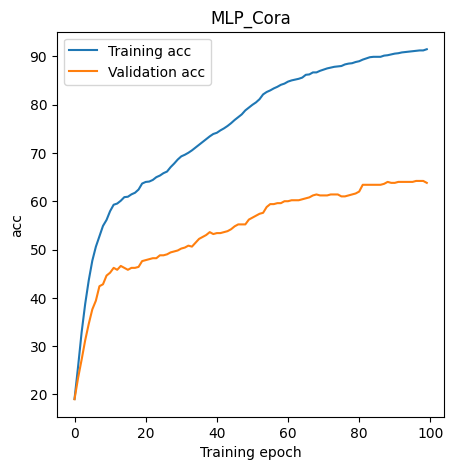

In [10]:
# Instantiate our model
model = SimpleMLP(input_dim=train_x.shape[-1], output_dim=7)

# Run training loop
train_stats_mlp_cora = train_eval_loop(model, train_x, train_y, valid_x, valid_y, test_x, test_y)
plot_stats(train_stats_mlp_cora, name="MLP_Cora")

# Part 1: From Heat Diffusion to GNNs

Before we dive into implementing some models, let's implement some simple functions that will be helpful later.






## 💻**Task 1:** Compute the symmetric normalised adjacency matrix of a graph with added self-loops.

For a graph without self loops, this is given by $$(\mathbf{D} + \mathbf{I})^{-
1/2}(\mathbf{A} + \mathbf{I})(\mathbf{D} + \mathbf{I})^{-1/2} = \tilde{\mathbf{D}}^{-
1/2}\tilde{\mathbf{A}}\tilde{\mathbf{D}}^{-1/2}$$ Where $\tilde{\mathbf{A}}$ is the $n \times n$ adjacency matrix with added self-loops. $\tilde{\mathbf{D}}$ is the degree matrix of $\tilde{\mathbf{A}}$, a diagonal matrix with entry $ii$ being the degree of node $i$.

The function below takes as input the dense matrix $A$ and should return a sparse version of the normalised adjacency in the coordinate format: https://pytorch.org/docs/stable/sparse.html#sparse-coo-docs. Make sure you use `torch.sparse.mm` when possible.

In [11]:
def sym_norm_adj(A):
    #### Create the symmetric normalised adjacency from the dense adj matrix A
    # This should return a sparse adjacency matrix. (torch sparse coo tensor format)

    #get the number of nodes
    n = A.size(0)
    #add self-loops to each node, by adding identity matrix to adjacency matrix
    A_tilde = A + torch.eye(n, device=A.device, dtype=A.dtype)

    #since D (the degree matrix) is diagonal, pre and post multiplying A by D corresponds to
    #multiplying each entry (i,j) in A by d_i^-1/2 * d_j^-1/2
    #here we compute the degrees of each node, and compute the inverse square root of these
    deg = A_tilde.sum(dim=1)
    deg_inv_sqrt = deg.pow(-0.5)
    deg_inv_sqrt[torch.isinf(deg_inv_sqrt)] = 0.0

    rows, cols = A_tilde.nonzero(as_tuple=True)
    #values is [num_of_non_zero_entries_in_A_tilde], and contains all non-zero values of the symmetric normalised adjacency matrix
    values = A_tilde[rows, cols] * deg_inv_sqrt[rows] * deg_inv_sqrt[cols]

    #indices is [2, num_of_non_zero_entries_in_A_tilde] and contains the non-zero indices (row, col) of the symmetric normalised adjacency matrix
    indices = torch.stack([rows, cols], dim=0)

    #we build a tensor of shape A_tilde, whose non-zero entries are specified by 'indices' tensor with corresponding values specified by the 'values' tensor
    return torch.sparse_coo_tensor(indices, values, A_tilde.shape).coalesce()


## Graph Laplacians
We will now focus on graph Laplacians and more importantly the role they play in heat diffusion. You have already encountered graph Laplacians in Practical 2, mostly having a look at their eigendecomposition. In this Practical, we are more interested instead in how they operate over signals. We define the graph Laplacian $\mathbf{L}$ as

$$\mathbf{L} = \mathbf{D} - \mathbf{A},$$

with $\mathbf{D} $ being the degree matrix and $\mathbf{A}$ the adjacency matrix for a graph $G$. The graph Laplacian is a symmetric positive semi-definite operator that acts over node signals and computes the "smootheness" of these node signals. By $\Delta$ we denote the (symmetrically) normalised version of the graph Laplacian (with added self-loops). This takes the form:

$$\Delta = \tilde{\mathbf{D}}^{-
1/2}\tilde{\mathbf{L}}\tilde{\mathbf{D}}^{-1/2} = \tilde{\mathbf{D}}^{-
1/2}(\tilde{\mathbf{D}} - \tilde{\mathbf{A}}) \tilde{\mathbf{D}}^{-1/2} = \mathbf{I} - \tilde{\mathbf{D}}^{-
1/2}\tilde{\mathbf{A}} \tilde{\mathbf{D}}^{-1/2},$$

where $\tilde{\mathbf{A}} = \mathbf{A} + \mathbf{I}$. The eigenvalues and eigenvectors of the graph Laplacian hold a lot of very useful information. They are tied to the connectivity of the graph and they have numerous important applications such as spectral graph clustering.

## Dirichlet Energy
For a feature matrix $X$, the Dirichlet energy is defined as $Tr(X^T \Delta X)$, where $\Delta$ is the symmetric normalised Laplacian. This is a measure of how "smooth" the signal is. We recall that a feature matrix $X \in \mathbb{R}^{n \times d}$ assigns to each of the $n$ nodes a $d$-dimensional feature vector. We can interpret this as a *vector field* over the graph.

To build intuition, let us consider a $1$-dimensional signal over the graph; that is to say, to each node we assign a scalar. Then, the Dirichlet energy is simply $\mathbf{x}^T \Delta \mathbf{x}$. Let $d_i$ be the *degree* of node $i$. The (normalised) Dirichlet energy looks as follows:

$$\mathbf{x}^T \Delta \mathbf{x} = \frac{1}{2}\sum_{(i, \ j)\in E}\left(\frac{\mathbf{x}_i}{\sqrt{d_i}} - \frac{\mathbf{x}_j}{\sqrt{d_j}}\right)^2 = \frac{1}{2}\sum_{(i, \ j)\in E}\nabla_{ij}^2$$

Where we let $\nabla_{ij} = \frac{\mathbf{x}_i}{\sqrt{d_i}} - \frac{\mathbf{x}_j}{\sqrt{d_j}}$, i.e. $\nabla_{ij}$ is a "gradient" over neighbouring nodes $i, j$ in the graph, with added normalisation. For the sake of discussion and intuition, we will now avoid this normalisation detail. It should be clear, assuming real-valued signals, that $\mathbf{x}^T \Delta \mathbf{x} \geq 0$, meaning that $\Delta$ is a positive semi-definite operator. Values close to $0$ are ones in which the signal is "smooth" as we jump from node to node, as the only way for the Dirichlet energy to be close to $0$ is when all the gradients $\nabla_{ij}$ are small. We achieve $0$ (assuming the graph is connected) only when we have a constant signal. The constant signal is in fact an eigenvector of the Laplacian, with corresponding eigenvalue $0$. Of course, the normalisations add a slight complication to this discussion, but the intution remains roughly the same.

## 💻**Task 2:** Implement a function to compute the Dirichlet energy

Test your code by computing the Dirichlet energy on the raw features of Cora. You should get a value of around 30000.

Note: The Dirichlet energy is $Tr(X^T \Delta X) = \sum_{(i,\ j)\in E}{\left\|\frac{\mathbf{X}_i}{\sqrt{d_i}} -\frac{\mathbf{X}_j}{\sqrt{d_j}} \right\|_2^2}$. You should use the normalised adjacency matrix `adj_norm` to compute this quantity. For effiency reasons, avoid using `for` loops, but instead compute this with matrix operations.

In [12]:
def dirichlet_energy(X, adj_norm):
    # X is a matrix of shape (num_nodes, feature_channels)
    # adj_norm is a torch sparse coo tensor
    ######## Your code here ##############
    # Graph_laplacian = I - adj_norm
    # so Tr(X^T Graph_laplacian X) = Tr(X^T X) - Tr(X^T adj_norm X)
    AX = torch.sparse.mm(adj_norm, X)
    term1 = torch.trace(X.t() @ X)
    term2 = torch.trace(X.t() @ AX)
    energy = term1 - term2
    ######################################
    return energy

In [13]:
X = cora_data.get_fullx()
adj = cora_data.get_adjacency_matrix()
norm_adj = sym_norm_adj(adj)
energy = dirichlet_energy(X, norm_adj)
print(f"Initial Dirichlet enegy: {energy}")

Initial Dirichlet enegy: 30079.662109375


## Relationship between GCN and the Heat equation

Recall the form of the GCN model:

$$\mathbf{X}_{t+1} = \sigma(\mathbf{\tilde{D}}^{-1/2}\tilde{\mathbf{A}}\mathbf{\tilde{D}}^{-1/2}\mathbf{X}_{t}\mathbf{W}_t)$$

with $\mathbf{W}_t$ being a learnable weight matrix and $\sigma$ a non-linear function. By $t$ we denote the layer of the model.

Note that we can split this up into three components:

1. An "update" equation: $$\mathbf{X}_t = \mathbf{X}_t\mathbf{W}_t$$
2. A 'diffusion'/message passing step:
$$\mathbf{X}_{t+1} = \mathbf{\tilde{D}}^{-1/2}\tilde{\mathbf{A}}\mathbf{\tilde{D}}^{-1/2}\mathbf{X}_{t}$$
3. A nonlinearity: $$\mathbf{X}_{t+1}=\sigma\left(\mathbf{X}_{t+1}\right)$$

Your task is to derive the diffusion step of the GCN model from a unit timestep Euler discretisation of the gradient flow of the Dirichlet energy, otherwise known as the heat equation:
<!-- Your task is to derive the diffusion step of the GCN model from a unit timestep Euler discretisation of the heat diffuson PDE (over a graph) - in other words to show that the GCN model behaves like a discretised version of the Heat equation: -->

$$
\frac{\partial \mathbf{X}_t}{\partial t} = -\Delta \mathbf{X}_t
$$


### 💻**Task 3.1:** Relationship between Dirichlet energy and the Laplacian

Show that the gradient of the Dirichlet energy is the Laplacian:
$$\nabla_\mathbf{x} \left(\mathbf{x}^TL \mathbf{x} \right) = L \mathbf{x}.$$ For simplicity, here $L$ is the standard graph Laplacian (no normalisations).

Hint: Fix a node $v$ and compute the partial $\frac{\partial}{\partial \mathbf{x}_v} \frac{1}{2}\left(\sum_{i \sim j} (\mathbf{x}_i - \mathbf{x}_j)^2\right)$, and express it in terms of the Laplacian.


** Your answer here **
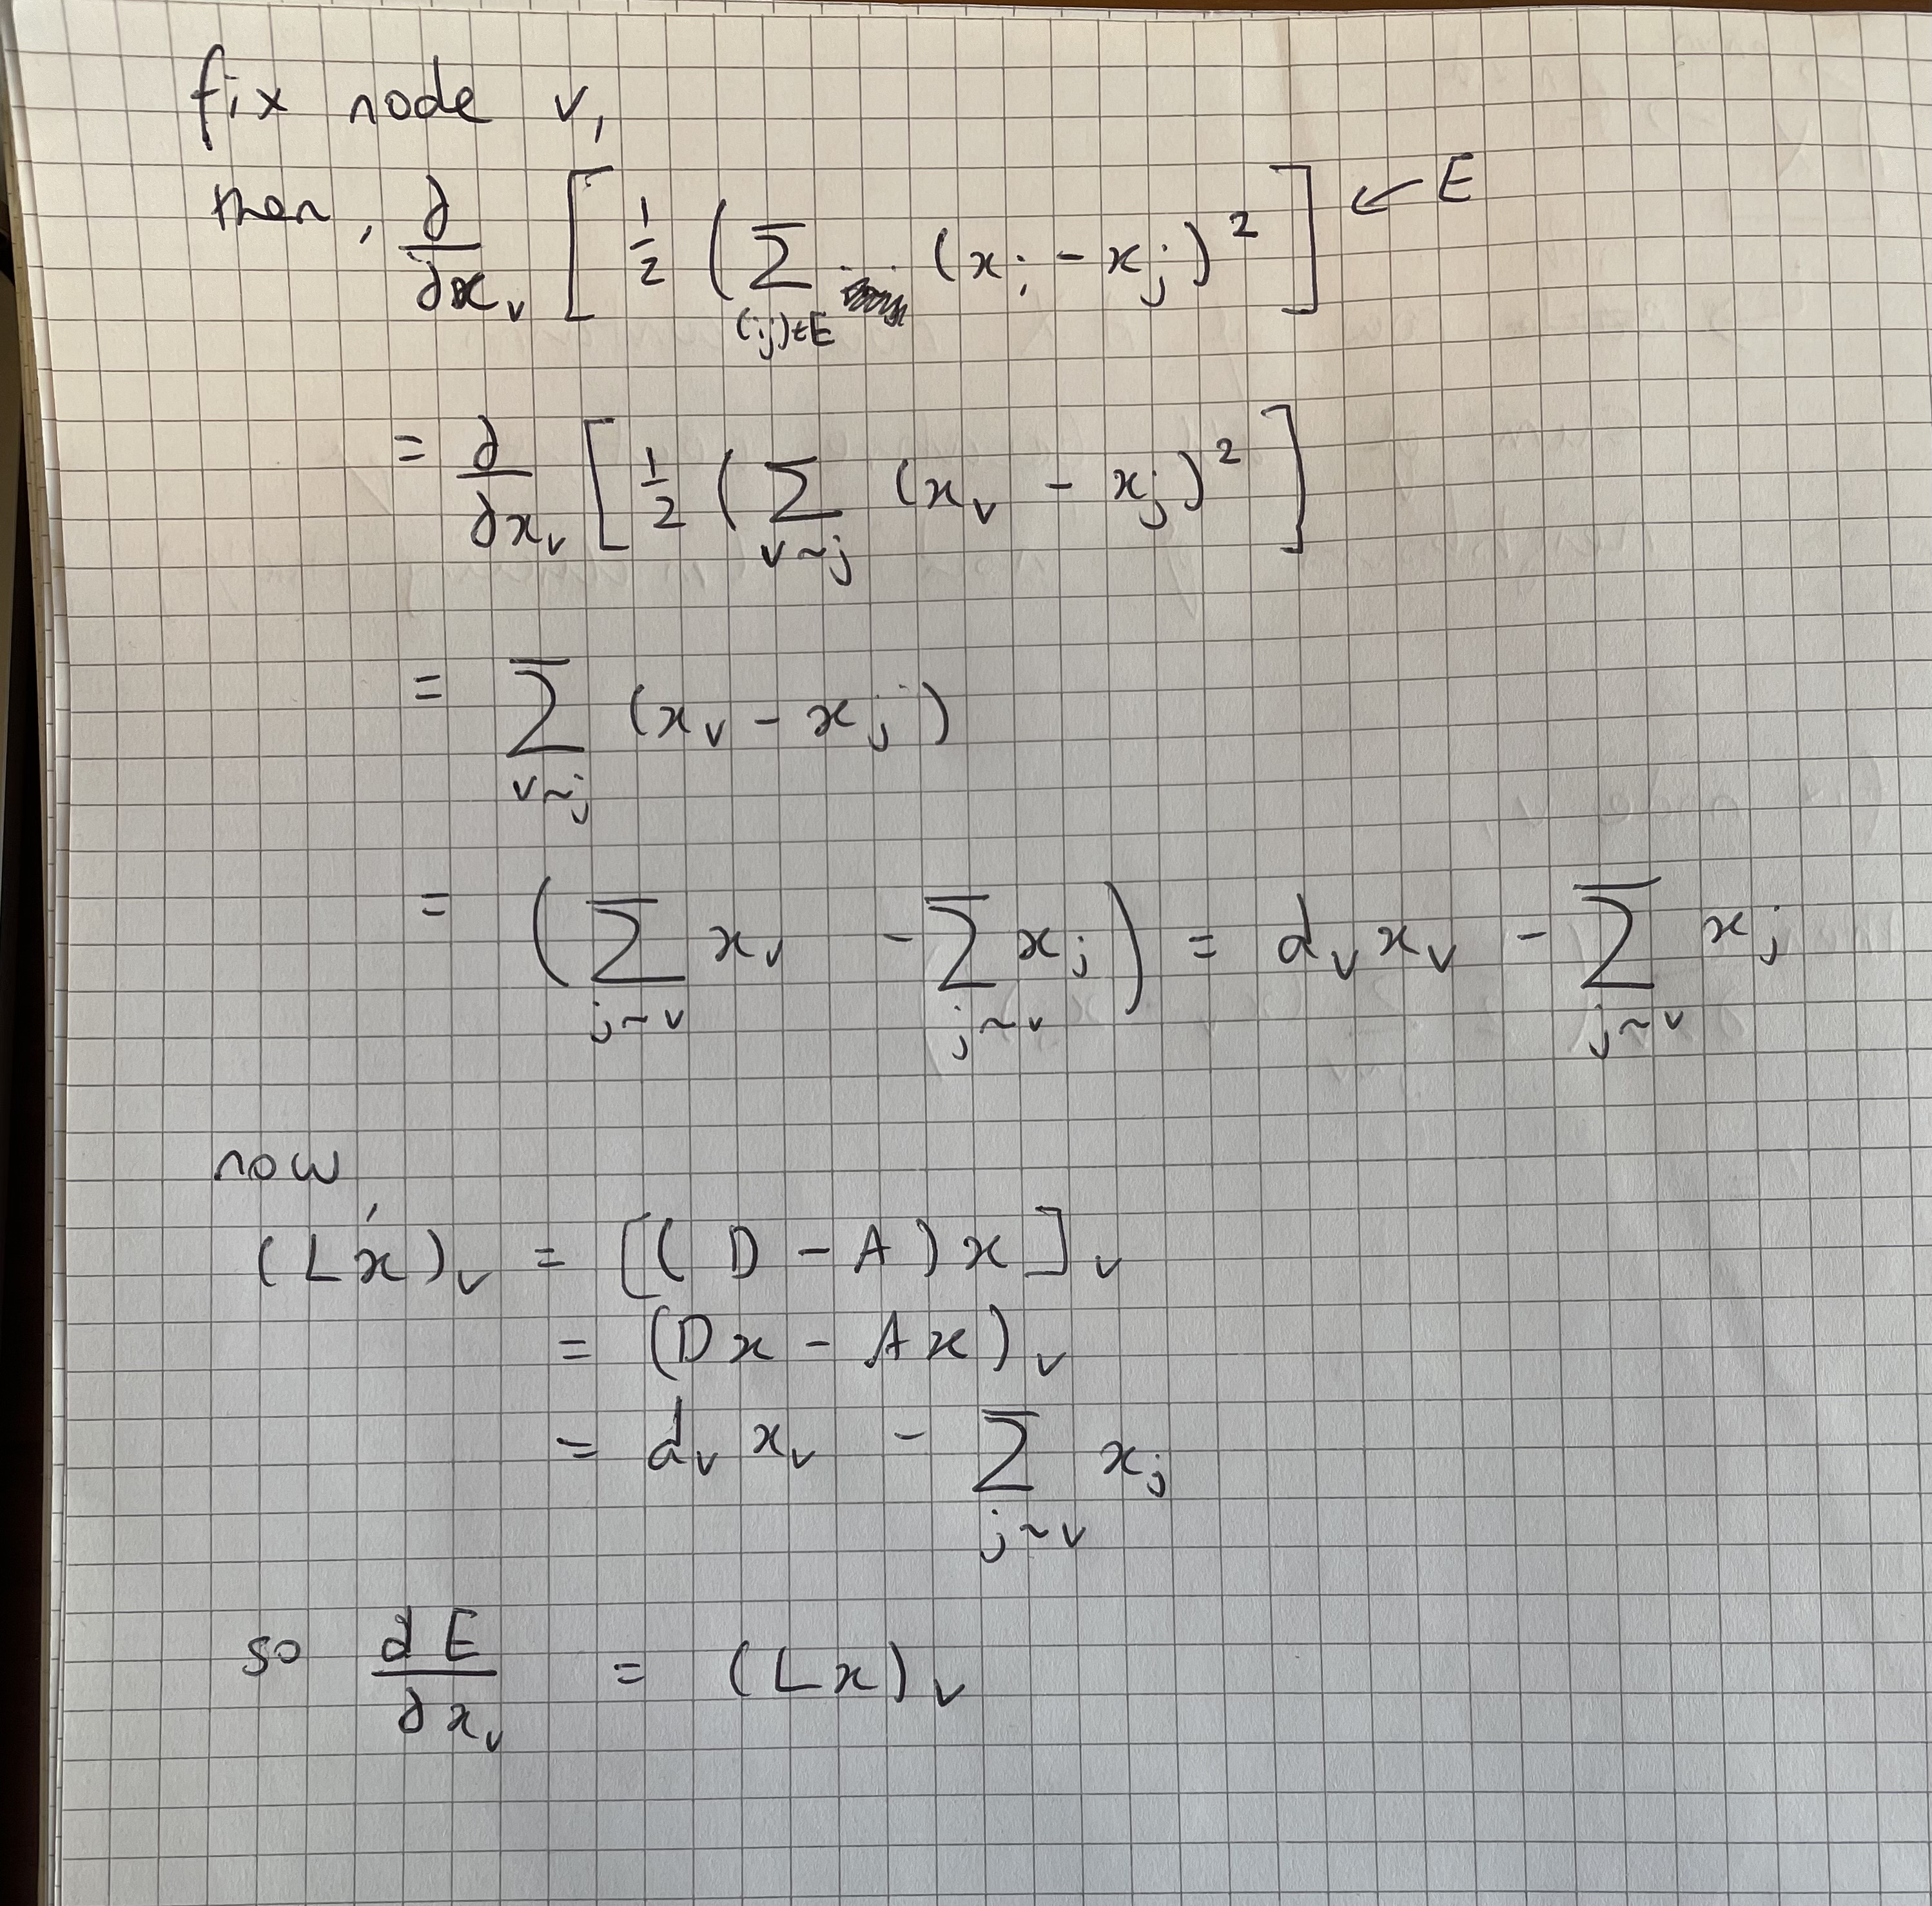

### 💻**Task 3.2:** Gradient descent

Write down the gradient descent equation of the features with time step $\tau$ (updating $\mathbf{x}$) updating them according to the gradient computed above. Conclude that for $τ=1$ we get the diffusion of equation 2 above.


** Your answer here **
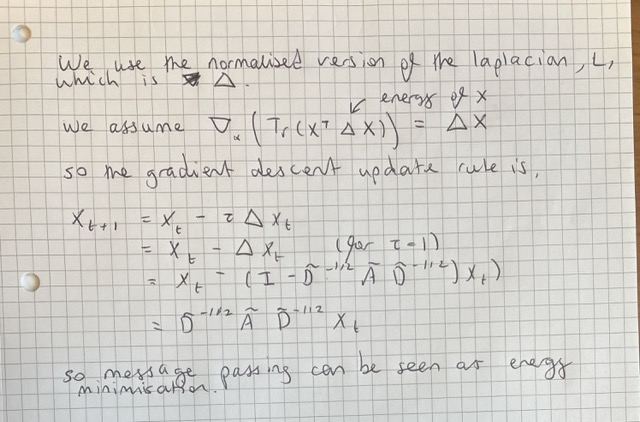

### 💻**Task 3.3: (BONUS)** Discretisation of the gradient flow

Write down the continuous gradient flow of the above equation, and observe that the Euler discretisation of the PDE gives the same result as question 2.

Hint: Given a continuous-time ordinary differential equation $\frac{\partial \mathbf{X}(t)}{\partial t} = F(t, \mathbf{X}_t)$, the Euler discretization with time step $\tau$ is: $$\frac{\mathbf{X}_{t+\tau} - \mathbf{X}_{t}}{\tau}= F(t, \mathbf{X}_{t})$$.


** Your answer here **
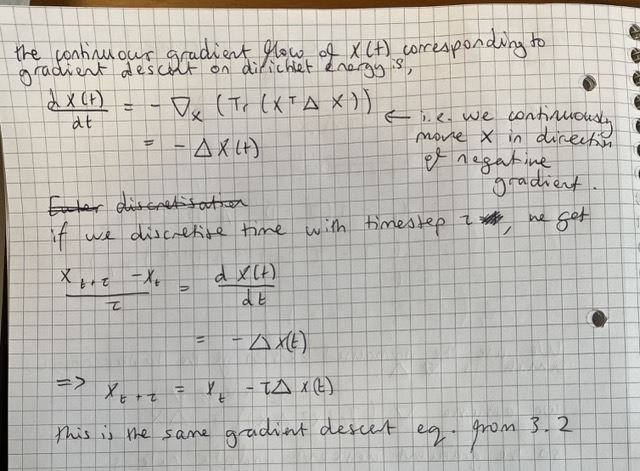

### 💻**Task 3.4: (BONUS)** Global minima of diffusion gradient flows

Show that at convergence of the gradient descent (or gradient flow) of question 2 we find ourselves in a global minima. Describe this global minimum. Link this to the phenomenon of over-smoothing in GNNs.

Hint: You are allowed to use the fact that the quadratic form $\mathbf{x}^T\Delta \mathbf{x}$ is convex without giving proof of this.

** Your answer here **
Since the dirichlet energy is convex (in X), anywhere we have a gradient of 0 is global minimum. So if gradient descent converges, i.e. the gradient diminimishes to 0 so that we stop moving our point X, then X must be at a global minimum.

The global minimum of the dirichlet energy is 0, and this occurs when every node has the same feature vector.

Over-smoothing is what happens when repeated diffusion / message passing makes node features too similar. This will make it difficult for the GNN to distinguish, and hence classify nodes.

## 💻**Task 4:** Implement the heat layer

We will now implement the Euler discretisation of heat diffusion. The heat diffusion equation is given by $\frac{\partial \mathbf{X}_t}{\partial t} = -\Delta \mathbf{X}_t$. For a step size $\tau$, we obtain the following layer $\mathbf{X}_{t+1} = \mathbf{X}_t - \tau \Delta \mathbf{X}_t$.

In [14]:
class HeatLayer(nn.Module):
    """Heat diffusion layer to be implemented by students of practical

    Args:
        input_dim (int): Dimensionality of the input feature vectors
        output_dim (int): Dimensionality of the output softmax distribution
        A (torch.Tensor): 2-D adjacency matrix
    """
    def __init__(self, input_dim, output_dim, A, step_size, use_W=True, nonlinear=False):
        super(HeatLayer, self).__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.A = A
        self.step_size = step_size
        self.adj_norm = sym_norm_adj(A)
        #############

    def forward(self, x):
        #############
        # Explicit Euler step for heat diffusion: X_{t+1} = X_t - tau * normalised_graph_laplacian * X_t,
        # with normalised_graph_laplacian = I - adj_norm.
        Ax = torch.sparse.mm(self.adj_norm, x)
        x_next = x - self.step_size * (x - Ax)
        return x_next
        #############

We provide below the code necessary to run these layers by stacking multiple such layers. Each layer corresponds to a discretised step of an underlying dynamical system.

In [15]:
#@title GNN Setup
class GNN(nn.Module):
    """Simple encoder decoder GNN model using the various conv layers implemented by students

    Args:
        input_dim (int): Dimensionality of the input feature vectors
        hidden_dim (int): Dimensionality of the hidden feature vectors
        output_dim (int): Dimensionality of the output softmax distribution
        time (int):
        step_size (int):
        A (torch.Tensor): 2-D adjacency matrix
        conv_type (str):
    """
    def __init__(self, input_dim, hidden_dim, output_dim, T, step_size, A, conv_type='gcn'):
        super(GNN, self).__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.tot_time = T
        assert step_size <= 1
        self.step_size = step_size
        self.layers = int(-(-T // step_size))  # division that rounds up
        self.A = A

        self.encoder = nn.Linear(input_dim, hidden_dim)
        if conv_type == 'heat':
          self.conv_layer = HeatLayer(hidden_dim, hidden_dim, A, step_size)
        elif conv_type == 'graff':
          self.conv_layer = GRAFFLayer(hidden_dim, hidden_dim, A, step_size)
        self.decoder = nn.Linear(hidden_dim, output_dim)

        self.evolution = []


    def forward(self, x):
        self.evolution = []
        x = self.encoder(x)

        for _ in range(self.layers):
          self.evolution.append(x)
          x = self.conv_layer(x)  # note implicitly we are sharing weights by using 1 conv block repeated

        self.evolution.append(x)
        x = self.decoder(x)

        y_hat = F.log_softmax(x, dim=1)
        return y_hat

In [16]:
#@title Training setup

def train_gnn_cora(X, y, mask, model, optimiser):
    model.train()
    optimiser.zero_grad()
    y_hat = model(X)[mask]
    loss = F.cross_entropy(y_hat, y)
    loss.backward()
    optimiser.step()
    return loss.data

def evaluate_gnn_cora(X, y, mask, model):
    model.eval()
    y_hat = model(X)[mask]
    y_hat = y_hat.data.max(1)[1]
    num_correct = y_hat.eq(y.data).sum()
    num_total = len(y)
    accuracy = 100.0 * (num_correct/num_total)
    return accuracy

# Training loop
def train_eval_loop_gnn_cora_evolutions(model, train_x, train_y, train_mask,
                        valid_x, valid_y, valid_mask,
                        test_x, test_y, test_mask
                    ):
    optimiser = optim.Adam(model.parameters(), lr=LR)
    training_stats = None
    evolutions = {}
    # Training loop
    for epoch in range(NUM_EPOCHS):
        train_loss = train_gnn_cora(train_x, train_y, train_mask, model, optimiser)
        train_acc = evaluate_gnn_cora(train_x, train_y, train_mask, model)
        valid_acc = evaluate_gnn_cora(valid_x, valid_y, valid_mask, model)
        if epoch % 10 == 0:
            print(f"Epoch {epoch} with train loss: {train_loss:.3f} train accuracy: {train_acc:.3f} validation accuracy: {valid_acc:.3f}")
            evolutions[f"epoch_{epoch}"] = model.evolution ### <-- adding this line to track the evolution

        # store the loss and the accuracy for the final plot
        epoch_stats = {'train_acc': train_acc, 'val_acc': valid_acc, 'epoch':epoch}
        training_stats = update_stats(training_stats, epoch_stats)
    # Lets look at our final test performance
    test_acc = evaluate_gnn_cora(test_x, test_y, test_mask, model)
    print(f"Our final test accuracy is: {test_acc:.3f}")
    return training_stats, evolutions

def evaluate_gnn_cora_evol(X, y, mask, model):
    model.eval()
    y_hat = model.decoder(X)[mask]
    y_hat = y_hat.data.max(1)[1]
    num_correct = y_hat.eq(y.data).sum()
    num_total = len(y)
    accuracy = 100.0 * (num_correct/num_total)
    return accuracy

In [21]:
#@title [RUN] Plotting methods
def get_evolution_stats(model, CoraDataset, evolutions, epoch_idxs=[-1]):

    A = CoraDataset.get_adjacency_matrix()
    edge_index = CoraDataset.cora_data.edge_index
    adj_norm = sym_norm_adj(A)
    train_mask = CoraDataset.train_mask
    valid_mask = CoraDataset.valid_mask
    test_mask = CoraDataset.test_mask

    evol_stats = {}
    for epoch in epoch_idxs:
      epoch_idx=f"epoch_{epoch}"
      evol_stats[epoch_idx] = {}

      train_accs = []
      val_accs = []
      test_accs = []
      energy = []

      for x_t in evolutions[epoch_idx]:
          logits = model.decoder(x_t)
          y_t = F.log_softmax(logits, dim=1)

          train_accs.append(evaluate_gnn_cora_evol(x_t, train_y, train_mask, model))
          val_accs.append(evaluate_gnn_cora_evol(x_t, valid_y, valid_mask, model))
          test_accs.append(evaluate_gnn_cora_evol(x_t, test_y, test_mask, model))
          energy.append(dirichlet_energy(x_t, adj_norm))


      evol_stats[epoch_idx]['train_accs'] = train_accs
      evol_stats[epoch_idx]['valid_accs'] = val_accs
      evol_stats[epoch_idx]['test_accs'] = test_accs
      evol_stats[epoch_idx]['energy'] = energy

      return evol_stats


def plot_evol_stats(evol_stats, figsize=(5, 5), name="", step_size=1.0, tot_time=3.0):
    """ Create four plots for each epoch stored in evol_stats
    """
    sorted_epochs = sorted(list(evol_stats.keys()))

    f, ax = plt.subplots(len(sorted_epochs), 2, figsize=figsize)

    x = np.arange(0, tot_time+step_size/2, step_size)

    for i, epoch in enumerate(sorted_epochs):
      stats = evol_stats[epoch]
      if len(sorted_epochs) > 1:
          #plot accuracies and homophily
          ax[i, 0].plot(x, torch.stack(evol_stats[epoch]['train_accs']).numpy())
          ax[i, 0].plot(x, torch.stack(evol_stats[epoch]['valid_accs']).numpy())
          ax[i, 0].plot(x, torch.stack(evol_stats[epoch]['test_accs']).numpy())
          ax[i, 0].legend()
          ax[0].set_ylabel("Accuracy")
          ax[0].set_xlabel("Time Evolution")
          #plot dirichlet energy
          ax[i, 1].plot(x, torch.stack(evol_stats[epoch]['energy']).numpy())
          ax[1].set_ylabel("Dirichilet Energy")
          ax[1].set_xlabel("Time Evolution")
          ax[0].set_title("Accuracy Evolution")
          ax[1].set_title("Dirichilet Energy Evolution")
          ax[i, 1].legend()
      else:
          ax[0].plot(x, torch.stack(evol_stats[epoch]['train_accs']).detach().cpu().numpy(), label='Train accuracy')
          ax[0].plot(x, torch.stack(evol_stats[epoch]['valid_accs']).detach().cpu().numpy(), label='Validation accuracy')
          ax[0].plot(x, torch.stack(evol_stats[epoch]['test_accs']).detach().cpu().numpy(), label='Test accuracy')
          ax[0].legend()
          #plot dirichlet energy
          ax[1].plot(x, torch.stack(evol_stats[epoch]['energy']).detach().cpu().numpy(), label='Energy')
          ax[0].set_ylabel("Accuracy")
          ax[0].set_xlabel("Time Evolution")
          ax[1].set_ylabel("Dirichilet Energy")
          ax[1].set_xlabel("Time Evolution")
          ax[0].set_title("Accuracy Evolution")
          ax[1].set_title("Dirichilet Energy Evolution")
        #   ax[1].ylabel("Energy")
          ax[1].legend()

In [18]:
# @title [RUN] Run heat diffusion

CONV_TYPE =  "heat"
NUM_EPOCHS =  100 #@param {type:"integer"}
LR         = 0.001 #@param {type:"number"}

In [19]:
# Instantiate our model and optimiser
Cora  = CoraDataset()
A = Cora.get_adjacency_matrix()
X = Cora.get_fullx()
model = GNN(input_dim=train_x.shape[-1], hidden_dim=32, output_dim=7, T=3., step_size=1., A=A, conv_type=CONV_TYPE)
###todo need to check why heat equation is so slow - probs not sparse

print(train_x.shape)
train_mask = Cora.train_mask
valid_mask = Cora.valid_mask
test_mask = Cora.test_mask

# Run training loop
train_stats_gnn_cora, evolutions = train_eval_loop_gnn_cora_evolutions(model, X, train_y, train_mask,
                                          X, valid_y, valid_mask,
                                          X, test_y, test_mask
                                       )


torch.Size([1208, 1433])
Epoch 0 with train loss: 1.953 train accuracy: 9.437 validation accuracy: 7.800
Epoch 10 with train loss: 1.804 train accuracy: 44.536 validation accuracy: 47.000
Epoch 20 with train loss: 1.646 train accuracy: 50.414 validation accuracy: 51.400
Epoch 30 with train loss: 1.482 train accuracy: 59.520 validation accuracy: 59.200
Epoch 40 with train loss: 1.311 train accuracy: 72.185 validation accuracy: 69.800
Epoch 50 with train loss: 1.141 train accuracy: 79.139 validation accuracy: 75.000
Epoch 60 with train loss: 0.980 train accuracy: 84.437 validation accuracy: 80.800
Epoch 70 with train loss: 0.836 train accuracy: 87.334 validation accuracy: 82.400
Epoch 80 with train loss: 0.715 train accuracy: 88.742 validation accuracy: 84.800
Epoch 90 with train loss: 0.616 train accuracy: 90.066 validation accuracy: 85.200
Our final test accuracy is: 86.500


Final Dirichlet energy: 469.786


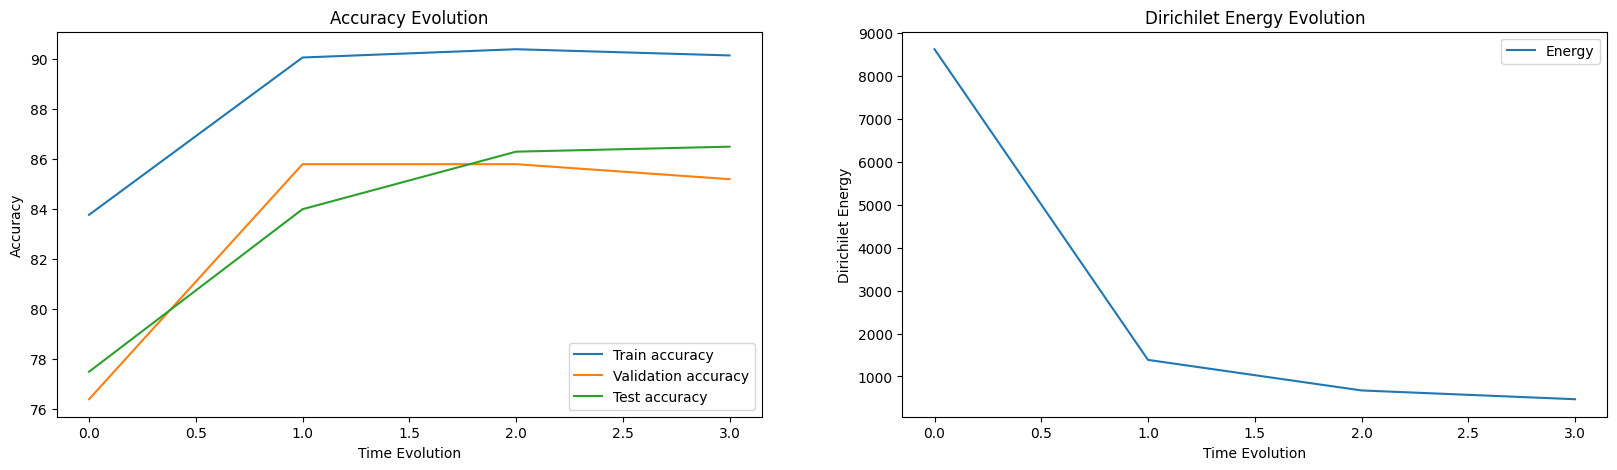

In [22]:
evol_stats = get_evolution_stats(model, Cora, evolutions, epoch_idxs=[NUM_EPOCHS-10])
plot_evol_stats(evol_stats, figsize=(20, 5), name="GNN_Cora", step_size=model.step_size, tot_time=model.tot_time)
print(f"Final Dirichlet energy: {evol_stats['epoch_90']['energy'][-1]:.3f}")


## 💻**Task 5:** Dirichlet energy behaviour

Examine the plots above, how does the Dirichlet energy behave as we run the Heat diffusion process? Why does this happen? Can you relate this to over-smoothing?

*Hint: This is very much related to the behaviour of Heat diffusion in a physical system.*

Answer here.

The Dirichlet energy decreases steadily as heat diffusion runs. That is because diffusion smooths the node features, making neighboring nodes more similar, and the Dirichlet energy exactly measures these edgewise differences, so smoothing drives it down toward its minimum.

This is  related to over-smoothing in GNNs. At first, smoothing can help accuracy by denoising features, but if diffusion continues too long, node representations become too similar across the graph. In the limit, features approach a nearly constant signal, so nodes become hard to distinguish and performance can stop improving or degrade.

## 💻**(Bonus) Task 6:** Implement a GRAFF layer

We will now implement a simple GRAFF layer from https://arxiv.org/abs/2206.10991. This is like a residual GCN with symmetric weight matrix $\mathbf{W}$ and no nonlinearities (although you are welcome to play around with nonlinear activations).

Denoting the symmetric normalised adjacency by $\tilde{\mathbf{A}}$, we want to implement $\mathbf{X}_{t+1} = \mathbf{X}_t + \tau\tilde{\mathbf{A}}\mathbf{X}_t \mathbf{W}$, where $\mathbf{W}$ is constrained to be symmetric and $\tau$ is again the step-size. Think how you can construct $\mathbf{W}$ so that it is forced to be symmetric. The technical details of GRAFF are beyond the scope of this practical - one take home message is that we are able to construct models (such as GRAFF) in which the Dirichlet energy does not have to necessarily vanish (like in GCNs for instance).

In [ ]:

class GRAFFLayer(nn.Module):
    """GRAFF layer to be implemented by students of practical

    Args:
        input_dim (int): Dimensionality of the input feature vectors
        output_dim (int): Dimensionality of the output softmax distribution
        A (torch.Tensor): 2-D adjacency matrix
    """
    def __init__(self, input_dim, output_dim, A, step_size, use_W=True, nonlinear=False):
        super(GRAFFLayer, self).__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.use_W = use_W
        self.nonlinear = nonlinear
        self.A = A
        self.step_size = step_size
        self.adj_norm = sym_norm_adj(A)
        # + Simple linear transformation and non-linear activation
        if self.use_W:
            self.linear = nn.Linear(input_dim, output_dim, bias=False)
        #############

    def forward(self, x):
        #############
        raise NotImplementedError("Implement me!")
        #############


In [ ]:
# @title [RUN] Run GRAFF diffusion

CONV_TYPE =  "graff"
NUM_EPOCHS =  100 #@param {type:"integer"}
LR         = 0.001 #@param {type:"number"}

In [ ]:
# Instantiate our model and optimiser
Cora  = CoraDataset()
A = Cora.get_adjacency_matrix()
X = Cora.get_fullx()
model = GNN(input_dim=train_x.shape[-1], hidden_dim=32, output_dim=7, T=3, step_size=0.2, A=A, conv_type=CONV_TYPE)
###todo need to check why heat equation is so slow - probs not sparse

print(train_x.shape)
train_mask = Cora.train_mask
valid_mask = Cora.valid_mask
test_mask = Cora.test_mask

# Run training loop
train_stats_gnn_cora, evolutions = train_eval_loop_gnn_cora_evolutions(model, X, train_y, train_mask,
                                          X, valid_y, valid_mask,
                                          X, test_y, test_mask
                                       )

In [ ]:
evol_stats = get_evolution_stats(model, Cora, evolutions, epoch_idxs=[NUM_EPOCHS-10])
plot_evol_stats(evol_stats, figsize=(20, 5), name="GNN_Cora",  step_size=model.step_size, tot_time=model.tot_time)
print(f"Final Dirichlet energy: {evol_stats['epoch_90']['energy'][-1]:.3f}")


## 💻**(Bonus) Task 7:** Interpret a GRAFF layer

What do you observe in the above Dirichlet energy plot? What is different to the GCN energy plot from before?

** Your answer here **

In this practical we started by looking at graph Laplacians and Dirichlet energies. We then related the Heat diffusion equation to GCNs. We saw how this type of process acts as a smoothing process of the features, meaning that the Dirichlet energy goes to $0$. In the bonus task we looked at a technique designed to change this behaviour.

Fin.

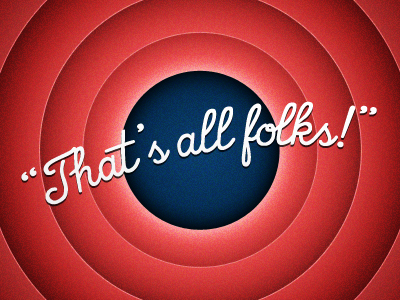